In [78]:
import scanpy as sc
import sys
import sys
sys.path.append('/Users/amossi/Documents/code')
from scipy.spatial import KDTree
import numpy as np
import squidpy as sq
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl
import warnings
warnings.filterwarnings('ignore')

%load_ext autoreload
%autoreload 2

# make font changeable in Illustrator
mpl.rcParams['pdf.fonttype'] = 42

# save figure with no pad
mpl.rcParams['savefig.pad_inches'] = 0
mpl.rcParams['savefig.bbox'] = 'tight'

# set axes width
mpl.rcParams['axes.linewidth'] = 0.2
mpl.rcParams['xtick.minor.pad'] = 0
mpl.rcParams['xtick.major.pad'] = 0
mpl.rcParams['ytick.minor.pad'] = 0
mpl.rcParams['ytick.major.pad'] = 0
mpl.rcParams['xtick.minor.width'] = 0.2
mpl.rcParams['xtick.major.width'] = 0.2
mpl.rcParams['ytick.minor.width'] = 0.2
mpl.rcParams['ytick.major.width'] = 0.2
# use colorblind seaborn style

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [ ]:
eel_path = '../../data_for_visualization/GBM_Linnarsson_EEL_revision.h5ad'
adata = sc.read_h5ad(eel_path)
rename_dic = {
    'WR 5':'WR Endo.Ass.',
    'WR 2':'WR Periphery1',
    'WR 3':'WR Periphery2',
    'WR 1':'WR Periphery3',
    
    'WR 6':'WR HYPR1',
    'WR 8':'WR HYPR2',
    'WR 7':'WR OPC',
    'WR 4':'WR nIPC',
    'nIPC-RG-like':'RG-like',
 
}

adata.obs['m-states'] = pd.Categorical([rename_dic[m] if m in rename_dic else m for m in adata.obs['m-states']])
adata.obs['m-states'] = pd.Categorical(['Mural' if m.count('Mural') else m for m in adata.obs['m-states']])

In [115]:
palette = {
    'AC-like 1':'#2ecc71',#inchworm B4FF9F
    'AC-like 2':'#2ecc71',#inchworm B4FF9F
    'AC-like 3':'#2ecc71',#inchworm B4FF9F
    'AC-like 4':'#2ecc71',#inchworm B4FF9F
    'AC-like 5':'#2ecc71',#inchworm B4FF9F
    'AC-like 6':'#2ecc71',#inchworm B4FF9F
    'AC-like 7':'#2ecc71',#inchworm B4FF9F

    'preOPC-like':'#7befb2',#'#c2f970'

    'WR Endo.Ass.':'#e76d89',# Deep cerise
    'WR Periphery1':'#e76d89',# Deep cerise
    'WR Periphery2':'#e76d89',# Deep cerise
    'WR Periphery3':'#e76d89',# Deep cerise
    'WR HYPR1':'#e76d89',# Deep cerise
    'WR HYPR2':'#e76d89',# Deep cerise
    'WR nIPC':'#e76d89',# Deep cerise
    'WR OPC':'#e76d89',# Deep cerise
    
    'RG-like':'#ff9470',
    'nIPC-RG-like':'#ff9470',
    'nIPC-like 3':'#FFF192',

    'OPC-like 2':'#89c4f4', #bright turquoise
    
    'TAM-BDM 1':'#e3ba8f', #wood
    'TAM-BDM 2':'#e3ba8f',
    'TAM-BDM 3':'#e3ba8f',
    'TAM-BDM 4':'#e3ba8f', #wood

    'TAM-MG':'#a6915c',#red orange
    'Mono 1': '#f4ede4',
    'Mono 2': '#f4ede4',
    
    'Oligodendrocyte':'#392e4a',
    'Astrocyte':'#038aff',
    
    'Endothelial':'#d5b8ff', # '#d5b8ff',  
    'Mural':'#8c14fc',#d5b8ff',  

}


# All Samples

In [116]:
import pickle
dic_nhood = pickle.load(open('../Figure 4/CellStateNN_20240528-2.pkl', 'rb'))

In [ ]:
from sklearn.preprocessing import StandardScaler, Normalizer, MinMaxScaler, RobustScaler
import scipy.cluster.hierarchy as hc
from scipy.spatial.distance import pdist
from sklearn.preprocessing import scale
from scipy.cluster.hierarchy import dendrogram
import fastcluster

mutation_df = pd.read_parquet('../../data_for_visualization/MutationsPatients.parquet')
import seaborn as sns
_palette = sns.color_palette("hls", mutation_df.shape[1])
paletteMutations = {}
for col, gene in zip(_palette, mutation_df.columns):
    paletteMutations[gene] = col
'''for m, col in paletteMutations.items():
    print(m , mpl.colors.to_hex(col))'''

'for m, col in paletteMutations.items():\n    print(m , mpl.colors.to_hex(col))'

In [118]:
df_samples = pd.DataFrame(
    data=np.array(
        [
            #StandardScaler().fit_transform(dic_nhood[k].fillna(0).values).flatten() for k in dic_nhood
            StandardScaler().fit_transform(dic_nhood[k].replace([np.inf, -np.inf, np.nan], 0)).flatten() for k in dic_nhood
            #dic_nhood[k].values.flatten() for k in dic_nhood
        ]
    ).T, 
    columns=list(dic_nhood.keys())
)

#X = StandardScaler().fit_transform(df_samples.values.T)
#df_samples = pd.DataFrame(data=X.T, index=df_samples.index, columns=df_samples.columns)

In [140]:
metric = 'cosine'
method = 'complete'
D = pdist(df_samples.dropna().T, metric=metric)
#D[np.isnan(D)] = 0
Z = fastcluster.linkage(D, method=method, metric=metric, preserve_input=True)
Z = hc.optimal_leaf_ordering(Z, D, metric=metric)
ordering_samples = hc.leaves_list(Z)

In [141]:
samples

array(['SL001A', 'SL001B', 'SL002', 'SL003', 'SL005', 'SL006', 'SL011',
       'SL012', 'SL013', 'SL015', 'SL016A', 'SL016B', 'SL018', 'SL019',
       'SL020', 'SL023', 'SL027B', 'SL029', 'SL030', 'SL034', 'SL035A',
       'SL035B', 'SL037', 'SL038', 'SL040B', 'SL040Bulk', 'SL040C',
       'SL040D', 'SL040E', 'SL040F', 'SL040G', 'SL046A', 'SL046B',
       'SL046C', 'SL047B', 'SL053', 'SL057A', 'SL057B', 'SL061A',
       'SL061B', 'SL061C'], dtype='<U9')

In [142]:
samples = list(dic_nhood.keys())


organization = {
        'GBM': ['IDH', '1p19q'],
        'RTK': ['PIK3','EGFRamp', 'EGFRmut', 'PDGFRA', 'PDGFA', 'PTEN', 'NF1'],
        'p53': ['p53', 'MDM'],
        'RB':['RB1','CDK2NA/B','CDK'],
        'Other':['DNMT3A','MGMT','TERT','GLI1','MET']
                }

mutation_loc = [
    'IDH', '1p19q', 
    'PIK3','EGFRamp', 'EGFRmut', 'PDGFRA', 'PDGFA', 'PTEN', 'NF1',
    'p53', 'MDM',
    'RB1','CDK2NA/B','CDK',
    'DNMT3A','MGMT','TERT','GLI1','MET',
]


paletteMutations = {}
#for col, gene in zip(_palette, mutation_df.columns):
#    paletteMutations[gene] = col
#for m in organization:
#    
_palette = sns.color_palette("hls", mutation_df.shape[1]+2)
print(len(_palette), len(mutation_loc))
for c, m in zip(_palette, mutation_loc):
    #print(c,m)
    paletteMutations[m] = c
mutation_df = mutation_df.loc[:,mutation_loc]

21 19


INFO:fontTools.subset:maxp pruned
INFO:fontTools.subset:cmap pruned
INFO:fontTools.subset:kern dropped
INFO:fontTools.subset:post pruned
INFO:fontTools.subset:FFTM dropped
INFO:fontTools.subset:GPOS pruned
INFO:fontTools.subset:GSUB pruned
INFO:fontTools.subset:glyf pruned
INFO:fontTools.subset:Added gid0 to subset
INFO:fontTools.subset:Added first four glyphs to subset
INFO:fontTools.subset:Closing glyph list over 'MATH': 26 glyphs before
INFO:fontTools.subset:Glyph names: ['.notdef', '.null', 'A', 'B', 'C', 'D', 'E', 'F', 'G', 'L', 'S', 'eight', 'five', 'four', 'k', 'l', 'nine', 'nonmarkingreturn', 'one', 'seven', 'six', 'space', 'three', 'two', 'u', 'zero']
INFO:fontTools.subset:Glyph IDs:   [0, 1, 2, 3, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 36, 37, 38, 39, 40, 41, 42, 47, 54, 78, 79, 88]
INFO:fontTools.subset:Closed glyph list over 'MATH': 26 glyphs after
INFO:fontTools.subset:Glyph names: ['.notdef', '.null', 'A', 'B', 'C', 'D', 'E', 'F', 'G', 'L', 'S', 'eight', 'five', 'four', 

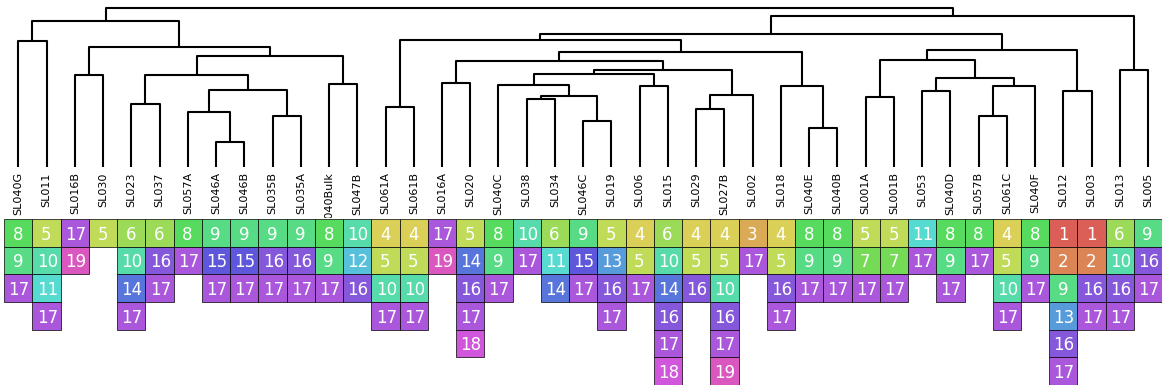

In [143]:
from matplotlib.patches import Rectangle
figsize = (15,5)
fig, axs = plt.subplots(nrows=2, ncols=1, figsize=figsize, sharex=True,gridspec_kw={'hspace':0.3}, height_ratios=(2,2))

ax = axs[0]
samples = np.array(samples)
out = dendrogram(Z,labels=df_samples.columns, ax = ax, above_threshold_color='black', color_threshold=0)
spines = ["top","right","left","bottom"]
for s in spines:
    ax.spines[s].set_visible(False)
ax.set_yticks([])
ax = axs[1]

for i,s in enumerate(samples[ordering_samples]):
    patient = s[:5]
    mut = mutation_df.loc[patient]
    mut = mut[mut != 0].index.tolist()
    for c, m in enumerate(mut):
        #loc = mutation_loc.index(m)
        #ax.scatter(i*10+5, loc,marker='s', s=150, color=paletteMutations[m])
        ax.add_patch(Rectangle(
            xy=(i*10, c*10) ,width=10, height=10,fill=True,edgecolor='black',facecolor = paletteMutations[m],#color=paletteMutations[m], 
            linewidth=.5, )
            )
        
        if mutation_loc.index(m)+1 > 9:
            extra=1.5
        else:
            extra = 3
        ax.annotate(
            text=mutation_loc.index(m)+1, xy=(i*10+extra, c*10+7.5),fontsize=12,color='white',
            )
            
ax.set_yticks([])
#ax.set_xticks([])
spines = ["top","right","left","bottom"]
for s in spines:
    ax.spines[s].set_visible(False)
ax.invert_yaxis()   
ax.set_xlim(-.1*figsize[0], len(ordering_samples)*10+.1)
ax.set_ylim((len(mutation_loc)+1)*3, -.5)
#plt.setp(axs[0].get_xticklabels(),visible=True, color="r")
axs[0].tick_params(labelbottom=True)
axs[1].tick_params(labelbottom=False)
plt.tight_layout()
plt.savefig('figures/NNconservation.pdf',dpi=150,transparent=True)

In [146]:
tumor_and_endo = [
    'AC-like 1', 'AC-like 2', 'AC-like 3', 'AC-like 4', 'AC-like 5', 'AC-like 6', 'AC-like 7', 
    'preOPC-like', 
    #'WR Endo.Ass.', 'WR Periphery1', 'WR Periphery2', 'WR Periphery3', 'WR HYPR1', 'WR HYPR2', 'WR nIPC', 'WR OPC', 
    'RG-like', 'nIPC-RG-like', 
    'nIPC-like 1', 'nIPC-like 2', 'nIPC-like 3',
     'OPC-like 2', 
    'Endothelial',
    'Mural',
    'FB-like 2', 'FB-like 3'
]



In [147]:
#dics = pickle.load(open('../../CellStateNN_20230703.pkl','rb'))
dics = dic_nhood

In [148]:
dic_nhood['SL035B'].columns

Index(['AC-like 1', 'AC-like 2', 'AC-like 3', 'AC-like 4', 'AC-like 5',
       'AC-like 6', 'AC-like 7', 'preOPC-like', 'WR Endo.Ass.',
       'WR Periphery1', 'WR Periphery2', 'WR Periphery3', 'WR HYPR1',
       'WR HYPR2', 'WR nIPC', 'WR OPC', 'RG-like', 'nIPC-RG-like',
       'nIPC-like 3', 'OPC-like 2', 'TAM-BDM 1', 'TAM-BDM 2', 'TAM-BDM 3',
       'TAM-BDM 4', 'TAM-MG', 'Mono 1', 'Mono 2', 'Oligodendrocyte',
       'Astrocyte', 'Endothelial', 'Mural'],
      dtype='object')

INFO:fontTools.subset:maxp pruned
INFO:fontTools.subset:cmap pruned
INFO:fontTools.subset:kern dropped
INFO:fontTools.subset:post pruned
INFO:fontTools.subset:FFTM dropped
INFO:fontTools.subset:GPOS pruned
INFO:fontTools.subset:GSUB pruned
INFO:fontTools.subset:glyf pruned
INFO:fontTools.subset:Added gid0 to subset
INFO:fontTools.subset:Added first four glyphs to subset
INFO:fontTools.subset:Closing glyph list over 'MATH': 36 glyphs before
INFO:fontTools.subset:Glyph names: ['.notdef', '.null', 'A', 'C', 'E', 'G', 'I', 'M', 'O', 'P', 'R', 'a', 'd', 'e', 'five', 'four', 'h', 'hyphen', 'i', 'k', 'l', 'minus', 'n', 'nonmarkingreturn', 'o', 'one', 'p', 'r', 'seven', 'six', 'space', 't', 'three', 'two', 'u', 'zero']
INFO:fontTools.subset:Glyph IDs:   [0, 1, 2, 3, 16, 19, 20, 21, 22, 23, 24, 25, 26, 36, 38, 40, 42, 44, 48, 50, 51, 53, 68, 71, 72, 75, 76, 78, 79, 81, 82, 83, 85, 87, 88, 3228]
INFO:fontTools.subset:Closed glyph list over 'MATH': 36 glyphs after
INFO:fontTools.subset:Glyph name

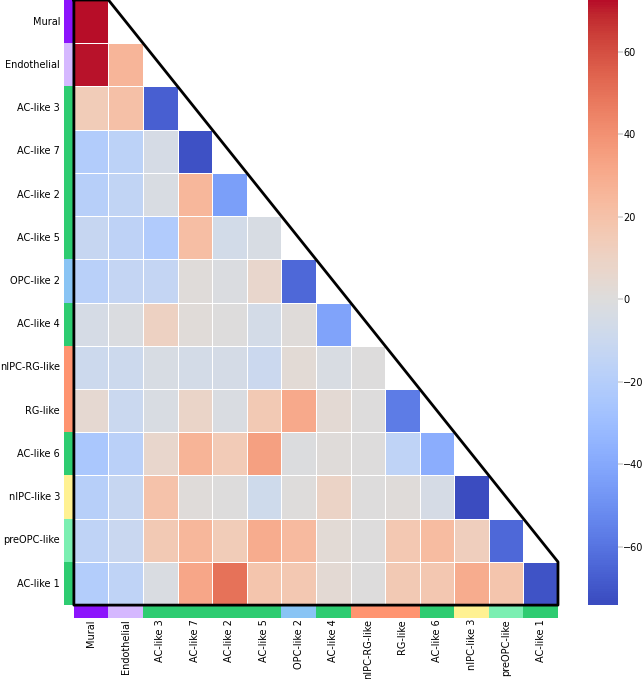

Index(['Mural', 'Endothelial', 'AC-like 3', 'AC-like 7', 'AC-like 2',
       'AC-like 5', 'OPC-like 2', 'AC-like 4', 'nIPC-RG-like', 'RG-like',
       'AC-like 6', 'nIPC-like 3', 'preOPC-like', 'AC-like 1'],
      dtype='object')

In [153]:

from sklearn.preprocessing import StandardScaler, RobustScaler

classes0 = tumor_and_endo
classes0 = np.array(classes0)
classes = []
for s in dics:
    classes += dics[s].index.tolist()
classes = np.unique(np.array(classes))
classes = classes0[np.isin(classes0, classes)]
df0 = dics[list(dics.keys())[0]]
df0 = df0.loc[classes][classes]
vals = np.zeros_like(df0.values)

for x in samples:
    df = dics[x]  
    df = df.loc[classes][classes]
    #X = StandardScaler().fit_transform(df.values)
    X = StandardScaler().fit_transform(df.replace([np.inf, -np.inf, np.nan], 0))
    #X = StandardScaler().fit_transform(X.T).T
    vals += X

NN_all = pd.DataFrame(data=vals, columns=classes, index = classes)

sp.pl.neighborhood_enrichment_from_pandas(
    NN_all,
    palette=palette,
    save=True,
    figsize=(7,7),
    mask_down=40, mask_up=40,
    savepath=f'figures/NN_all.pdf',
    
)